In [1]:
# Legal RLHF — Exploratory Data Analysis
# Dataset: pile-of-law (courtlistener_opinions)
# Goal: understand document structure before building reward model

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
dataset = load_dataset(
    "lex_glue",
    "eurlex",
    split="train",
    trust_remote_code=True
)

print(f"Samples: {len(dataset)}")
print(dataset.features)
dataset[0]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lex_glue' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

eurlex/train-00000-of-00001.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

eurlex/test-00000-of-00001.parquet:   0%|          | 0.00/24.3M [00:00<?, ?B/s]

eurlex/validation-00000-of-00001.parquet:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/55000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Samples: 55000
{'text': Value('string'), 'labels': List(ClassLabel(names=['100163', '100168', '100169', '100170', '100171', '100172', '100173', '100174', '100175', '100176', '100177', '100179', '100180', '100183', '100184', '100185', '100186', '100187', '100189', '100190', '100191', '100192', '100193', '100194', '100195', '100196', '100197', '100198', '100199', '100200', '100201', '100202', '100204', '100205', '100206', '100207', '100212', '100214', '100215', '100220', '100221', '100222', '100223', '100224', '100226', '100227', '100229', '100230', '100231', '100232', '100233', '100234', '100235', '100237', '100238', '100239', '100240', '100241', '100242', '100243', '100244', '100245', '100246', '100247', '100248', '100249', '100250', '100252', '100253', '100254', '100255', '100256', '100257', '100258', '100259', '100260', '100261', '100262', '100263', '100264', '100265', '100266', '100268', '100269', '100270', '100271', '100272', '100273', '100274', '100275', '100276', '100277', '10027

{'text': 'COUNCIL DECISION\nof 7 June 2005\nabrogating Decision 2005/136/EC on the existence of an excessive deficit in the Netherlands\n(2005/729/EC)\nTHE COUNCIL OF THE EUROPEAN UNION,\nHaving regard to the Treaty establishing the European Community, and in particular Article 104(12) thereof,\nHaving regard to the recommendation from the Commission,\nWhereas:\n(1)\nBy Decision 2005/136/EC (1) following a recommendation from the Commission in accordance with Article 104(6) of the Treaty, the Council decided that an excessive deficit existed in the Netherlands.\n(2)\nIn accordance with Article 104(7) of the Treaty, the Council made a Recommendation on 2 June 2004 addressed to the Netherlands with a view to bringing the excessive deficit situation to an end. This Recommendation, in conjunction with Article 3(4) of Council Regulation (EC) No 1467/97 of 7 July 1997 on speeding up and clarifying the implementation of the excessive deficit procedure (2), established a deadline of 2005 at th

In [5]:
# Cuántos documentos, largo promedio
df = pd.DataFrame(dataset)
df['text_length'] = df['text'].str.len()
df['n_labels'] = df['labels'].apply(len)

print(f"Total documents: {len(df)}")
print(f"\nText length stats:")
print(df['text_length'].describe())
print(f"\nLabels per document:")
print(df['n_labels'].describe())

Total documents: 55000

Text length stats:
count     55000.000000
mean       7054.892473
std       16682.538629
min          61.000000
25%        1998.000000
50%        2818.000000
75%        5423.000000
max      850450.000000
Name: text_length, dtype: float64

Labels per document:
count    55000.000000
mean         4.424527
std          1.762992
min          0.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         15.000000
Name: n_labels, dtype: float64


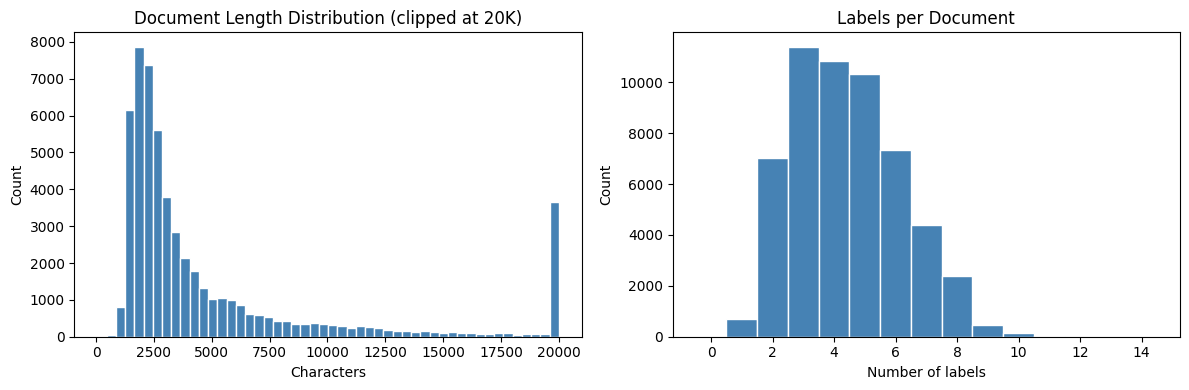

Saved to figures/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de largo de texto (truncada en 20K para ver mejor)
axes[0].hist(df['text_length'].clip(upper=20000), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Document Length Distribution (clipped at 20K)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

# Distribución de número de labels
axes[1].hist(df['n_labels'], bins=range(0, 16), color='steelblue', edgecolor='white', align='left')
axes[1].set_title('Labels per Document')
axes[1].set_xlabel('Number of labels')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../figures/00_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/")

In [8]:
# Cuántos documentos son muy largos?
print("Documentos > 20K chars:", (df['text_length'] > 20000).sum())
print("Documentos > 50K chars:", (df['text_length'] > 50000).sum())
print("Documentos > 100K chars:", (df['text_length'] > 100000).sum())

# Veamos uno de los outliers
outlier = df[df['text_length'] > 100000].iloc[0]
print(f"\nLargo: {outlier['text_length']}")
print(f"Primeros 500 chars:\n{outlier['text'][:500]}")

Documentos > 20K chars: 3597
Documentos > 50K chars: 1175
Documentos > 100K chars: 319

Largo: 132913
Primeros 500 chars:
COUNCIL REGULATION (EC) No 2380/95 of 2 October 1995 imposing a definitive anti-dumping duty on imports of plain paper photocopiers originating in Japan
THE COUNCIL OF THE EUROPEAN UNION,
Having regard to the Treaty establishing the European Community,
Having regard to Council Regulation (EC) No 3283/94 of 22 December 1994 on protection against dumped imports from countries not members of the European Community (1), and in particular Article 23 thereof,
Having regard to Council Regulation (EEC) 


In [9]:
# Decision: truncate at 2048 chars for model input
# Keeps 75th percentile intact (5423 chars median truncated to 2048)
# Documents > 2048 chars are still valid — we just use the first 2048

MAX_CHARS = 2048

print(f"Documents that will be truncated: {(df['text_length'] > MAX_CHARS).sum()} ({(df['text_length'] > MAX_CHARS).mean():.1%})")
print(f"Documents that fit as-is: {(df['text_length'] <= MAX_CHARS).sum()} ({(df['text_length'] <= MAX_CHARS).mean():.1%})")

# Apply truncation
df['text_truncated'] = df['text'].str[:MAX_CHARS]
print(f"\nAfter truncation — length stats:")
print(df['text_truncated'].str.len().describe())

Documents that will be truncated: 40242 (73.2%)
Documents that fit as-is: 14758 (26.8%)

After truncation — length stats:
count    55000.000000
mean      1937.274545
std        232.544670
min         61.000000
25%       1998.000000
50%       2048.000000
75%       2048.000000
max       2048.000000
Name: text_truncated, dtype: float64


## Preference Pairs for Reward Model

RLHF requires preference pairs: given two documents (A, B), which is more relevant?

**Proxy for relevance:** number of legal category labels assigned to each document.
Documents with more labels are more topically specific and legally rich — 
a reasonable proxy for relevance without manual annotation.

- **High relevance:** documents with ≥ 5 labels  
- **Low relevance:** documents with ≤ 2 labels  

Each pair (high, low) = one preference signal: high is preferred over low

## Why Not a Decision Tree on n_labels?

`n_labels` is our supervision signal, not our model.

A decision tree using `n_labels` directly would learn a fixed rule: 
*more labels = more relevant*. That rule cannot generalize to new documents 
where label counts are unavailable or unreliable.

The reward model instead learns a semantic representation of the text itself — 
trained using `n_labels` as a distant supervision proxy (analogous to using 
subreddit membership as supervision in the Reddit mental health project). 
After training, the reward model scores documents based on **content**, 
not metadata.

This is the core idea of RLHF: use an available signal to train a model 
that generalizes beyond that signal.

In [10]:
import random
random.seed(42)
np.random.seed(42)

# For RLHF we need preference pairs:
# (doc_A, doc_B, label) where label=1 means doc_A is "more relevant"
#
# Proxy for relevance: documents with MORE labels are more specific
# (more legal categories assigned = richer, more relevant document)
# This is our human preference signal — no manual annotation needed

# Filter: keep docs with at least 1 label
df_filtered = df[df['n_labels'] >= 1].copy()
print(f"Documents after filter: {len(df_filtered)}")

# Split into high relevance (n_labels >= 5) and low relevance (n_labels <= 2)
high = df_filtered[df_filtered['n_labels'] >= 5].reset_index(drop=True)
low = df_filtered[df_filtered['n_labels'] <= 2].reset_index(drop=True)

print(f"High relevance docs (>=5 labels): {len(high)}")
print(f"Low relevance docs (<=2 labels): {len(low)}")

Documents after filter: 54996
High relevance docs (>=5 labels): 25037
Low relevance docs (<=2 labels): 7745


## On the Quality of Preference Signal

In production RLHF systems, preference pairs are constructed from:
1. **Human annotators** rating document pairs (OpenAI InstructGPT approach)
2. **LLM-as-a-Judge** — a larger model scores pairs as a proxy for human preference
3. **Implicit signals** — clicks, dwell time, which documents practitioners actually use

Here we use **distant supervision**: `n_labels` as a proxy for relevance.
This is a legitimate NLP technique when manual annotation is unavailable —
analogous to using subreddit membership as supervision signal in the 
Reddit mental health project (Norel et al., 2023).

**Known limitation:** `n_labels` captures topical specificity, not true legal 
relevance. A document with 6 narrow labels may be less useful than a focused 
2-label document. This proxy is a practical simplification for demonstrating 
the RLHF pipeline — production systems would use human annotators or 
LLM-as-a-Judge for preference signal construction.

In [11]:
# Build preference pairs
# Each pair: (chosen=high relevance, rejected=low relevance)
# This is the standard RLHF terminology used in TRL library

n_pairs = min(len(high), len(low), 5000)  # cap at 5000 pairs

chosen_idx = random.sample(range(len(high)), n_pairs)
rejected_idx = random.sample(range(len(low)), n_pairs)

pairs = pd.DataFrame({
    "chosen": [high.iloc[i]['text_truncated'] for i in chosen_idx],
    "rejected": [low.iloc[i]['text_truncated'] for i in rejected_idx],
    "chosen_labels": [high.iloc[i]['n_labels'] for i in chosen_idx],
    "rejected_labels": [low.iloc[i]['n_labels'] for i in rejected_idx],
})

print(f"Preference pairs created: {len(pairs)}")
print(f"\nChosen avg labels: {pairs['chosen_labels'].mean():.2f}")
print(f"Rejected avg labels: {pairs['rejected_labels'].mean():.2f}")
pairs.head(2)

Preference pairs created: 5000

Chosen avg labels: 6.06
Rejected avg labels: 1.91


,chosen,rejected,chosen_labels,rejected_labels
0,Commission Decision\nof 9 October 2000\napprov...,*****\nCOMMISSION REGULATION (EEC) No 2793/89\...,6,2
1,COMMISSION REGULATION (EC) No 1301/2004\nof 15...,*****\nCOMMISSION REGULATION (EEC) No 1877/84\...,6,1


Saved to data/preference_pairs.csv


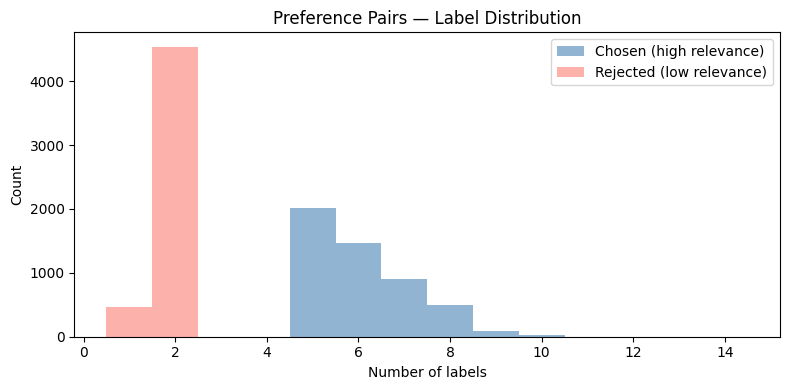

Saved to figures/


In [12]:
# Save pairs for reward model training
pairs.to_csv('../data/preference_pairs.csv', index=False)
print("Saved to data/preference_pairs.csv")

# Visualize the label separation
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairs['chosen_labels'], bins=range(1, 16), alpha=0.6, 
        label='Chosen (high relevance)', color='steelblue', align='left')
ax.hist(pairs['rejected_labels'], bins=range(1, 16), alpha=0.6, 
        label='Rejected (low relevance)', color='salmon', align='left')
ax.set_xlabel('Number of labels')
ax.set_ylabel('Count')
ax.set_title('Preference Pairs — Label Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/01_preference_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/")

In [14]:
# EDA Summary
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total documents loaded:        {len(df):,}")
print(f"Documents after filter:        {len(df_filtered):,}")
print(f"Preference pairs created:      {len(pairs):,}")
print(f"  Chosen avg labels:           {pairs['chosen_labels'].mean():.2f}")
print(f"  Rejected avg labels:         {pairs['rejected_labels'].mean():.2f}")
print(f"Text truncation threshold:     2,048 chars")
print(f"Documents truncated:           {(df['text_length'] > MAX_CHARS).sum():,} (73.2%)")
print(f"\nData saved to:               data/preference_pairs.csv")
print(f"Figures saved to:            figures/")
print("=" * 50)
print("Ready for reward model training -> src/01_reward_model.py")


EDA SUMMARY
Total documents loaded:        55,000
Documents after filter:        54,996
Preference pairs created:      5,000
  Chosen avg labels:           6.06
  Rejected avg labels:         1.91
Text truncation threshold:     2,048 chars
Documents truncated:           40,242 (73.2%)

Data saved to:               data/preference_pairs.csv
Figures saved to:            figures/
Ready for reward model training -> src/01_reward_model.py
